# 🍽️ Stage 1: Restaurant Reviews EDA & Machine Learning Baselines

This notebook performs:
1. Data audit and text preprocessing on the restaurant review dataset.
2. Exploratory Data Analysis (EDA) of star ratings and token distributions.
3. Grouped Reviewer train/val/test splitting to prevent style leakage.
4. TF-IDF feature extraction (1-2 grams).
5. Rigorous benchmarking of classical ML models:
   - Majority Class Floor
   - TF-IDF + Logistic Regression
   - TF-IDF + Linear SVM
   - TF-IDF + Random Forest
   - TF-IDF + XGBoost
6. Normalized confusion matrix generation and checkpoint persistence.


In [1]:
import os
import re
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix

import sys
PROJECT_ROOT = os.path.dirname(os.getcwd()) if 'notebooks' in os.getcwd() else os.getcwd()
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)
RAW_DATA_PATH = os.path.join(PROJECT_ROOT, 'data', 'raw', 'Restaurant reviews.csv')
PROCESSED_DIR = os.path.join(PROJECT_ROOT, 'data', 'processed')
MODELS_DIR = os.path.join(PROJECT_ROOT, 'models')
RESULTS_DIR = os.path.join(PROJECT_ROOT, 'results')

os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)
print("Working in Project Root:", PROJECT_ROOT)


Working in Project Root: D:\Aspect-Based-Sentimental-Analysis-on-Food-Reviews


## 1. Data Loading & Cleaning
Drop the corrupted `7514` header anomaly, drop empty or duplicate reviews, and map ratings to 3 sentiment categories:
- Negative: rating <= 2.0
- Neutral: 2.5 <= rating <= 3.5
- Positive: rating >= 4.0


In [2]:
raw_file = RAW_DATA_PATH if os.path.exists(RAW_DATA_PATH) else os.path.join(PROJECT_ROOT, 'data', 'Restaurant reviews.csv')
df = pd.read_csv(raw_file)

if '7514' in df.columns:
    df.drop(columns=['7514'], inplace=True)

df = df[df['Rating'] != 'Like'].copy()
df['Rating'] = pd.to_numeric(df['Rating'], errors='coerce')
df['Review'] = df['Review'].astype(str).str.strip()
df = df[df['Review'].str.len() > 3].copy()
df.dropna(subset=['Rating', 'Review', 'Restaurant'], inplace=True)
df.drop_duplicates(subset=['Restaurant', 'Review'], inplace=True)

def map_sentiment(r):
    if r <= 2.0:
        return 'Negative'
    elif r <= 3.5:
        return 'Neutral'
    else:
        return 'Positive'

df['Sentiment'] = df['Rating'].apply(map_sentiment)
label_map = {'Negative': 0, 'Neutral': 1, 'Positive': 2}
df['Label'] = df['Sentiment'].map(label_map)
df['Length'] = df['Review'].apply(len)
df['Word_Count'] = df['Review'].apply(lambda x: len(x.split()))

print(f"Total Cleaned Reviews: {len(df)}")
df[['Restaurant', 'Review', 'Rating', 'Sentiment']].head()


Total Cleaned Reviews: 9633


,Restaurant,Review,Rating,Sentiment
0,Beyond Flavours,"The ambience was good, food was quite good . h...",5.0,Positive
1,Beyond Flavours,Ambience is too good for a pleasant evening. S...,5.0,Positive
2,Beyond Flavours,A must try.. great food great ambience. Thnx f...,5.0,Positive
3,Beyond Flavours,Soumen das and Arun was a great guy. Only beca...,5.0,Positive
4,Beyond Flavours,Food is good.we ordered Kodi drumsticks and ba...,5.0,Positive


## 2. Exploratory Data Analysis

C:\Users\sohit\AppData\Local\Temp\ipykernel_14940\1842022778.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Sentiment', order=['Negative', 'Neutral', 'Positive'], palette=['#EF4444', '#F59E0B', '#10B981'], ax=axes[0])


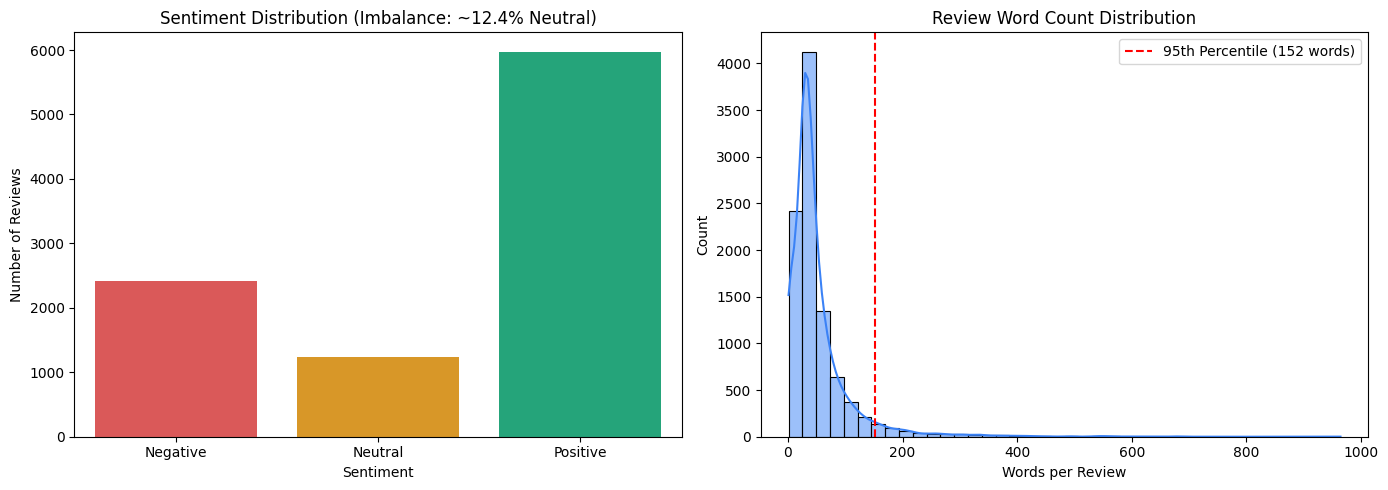

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sentiment class breakdown
sns.countplot(data=df, x='Sentiment', order=['Negative', 'Neutral', 'Positive'], palette=['#EF4444', '#F59E0B', '#10B981'], ax=axes[0])
axes[0].set_title('Sentiment Distribution (Imbalance: ~12.4% Neutral)')
axes[0].set_ylabel('Number of Reviews')

# Word count distribution
sns.histplot(df['Word_Count'], bins=40, kde=True, color='#3B82F6', ax=axes[1])
p95 = int(df['Word_Count'].quantile(0.95))
axes[1].axvline(p95, color='red', linestyle='--', label=f'95th Percentile ({p95} words)')
axes[1].set_title('Review Word Count Distribution')
axes[1].set_xlabel('Words per Review')
axes[1].legend()

plt.tight_layout()
plt.show()


## 3. Stratified Group Splitting (by Reviewer) & TF-IDF Extraction

In [4]:
from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(n_splits=1, train_size=0.70, random_state=42)
reviewer_groups = df['Reviewer'].fillna('Anonymous')
train_idx, temp_idx = next(gss.split(df, groups=reviewer_groups))

train_df = df.iloc[train_idx].reset_index(drop=True)
temp_df = df.iloc[temp_idx].reset_index(drop=True)

gss_val = GroupShuffleSplit(n_splits=1, train_size=0.50, random_state=42)
val_idx, test_idx = next(gss_val.split(temp_df, groups=temp_df['Reviewer'].fillna('Anonymous')))

val_df = temp_df.iloc[val_idx].reset_index(drop=True)
test_df = temp_df.iloc[test_idx].reset_index(drop=True)

print(f"Train Set: {len(train_df)} | Validation Set: {len(val_df)} | Test Set: {len(test_df)}")

# Fit TF-IDF on Train Set ONLY to prevent data leakage
tfidf = TfidfVectorizer(ngram_range=(1, 2), min_df=2, max_features=10000, sublinear_tf=True)
X_train = tfidf.fit_transform(train_df['Review'])
y_train = train_df['Label'].values

X_test = tfidf.transform(test_df['Review'])
y_test = test_df['Label'].values

joblib.dump(tfidf, os.path.join(MODELS_DIR, 'tfidf.pkl'))
print("TF-IDF vectorizer fitted and serialized to models/tfidf.pkl")


Train Set: 6727 | Validation Set: 1439 | Test Set: 1467


TF-IDF vectorizer fitted and serialized to models/tfidf.pkl


## 4. Train & Benchmark Classical ML Models

In [5]:
models = {
    'Majority Class Floor': DummyClassifier(strategy='most_frequent'),
    'TF-IDF + Logistic Regression': LogisticRegression(C=1.5, class_weight='balanced', max_iter=1000, random_state=42),
    'TF-IDF + Linear SVM': LinearSVC(C=0.8, class_weight='balanced', max_iter=2000, random_state=42),
    'TF-IDF + Random Forest': RandomForestClassifier(n_estimators=150, class_weight='balanced', max_depth=30, random_state=42, n_jobs=-1),
    'TF-IDF + XGBoost': XGBClassifier(n_estimators=150, max_depth=6, learning_rate=0.1, eval_metric='mlogloss', random_state=42, n_jobs=-1)
}

results = []
saved_models = {}

for name, model in models.items():
    print(f"Fitting {name}...")
    model.fit(X_train, y_train)
    saved_models[name] = model
    preds = model.predict(X_test)
    
    acc = accuracy_score(y_test, preds)
    p_macro, r_macro, f1_macro, _ = precision_recall_fscore_support(y_test, preds, average='macro', zero_division=0)
    p_cls, r_cls, f1_cls, _ = precision_recall_fscore_support(y_test, preds, average=None, zero_division=0)
    
    results.append({
        'Model': name,
        'Accuracy (%)': round(acc * 100, 2),
        'Macro-F1': round(f1_macro, 4),
        'Neg-F1': round(f1_cls[0], 4),
        'Neu-F1': round(f1_cls[1], 4),
        'Pos-F1': round(f1_cls[2], 4)
    })

joblib.dump(saved_models, os.path.join(MODELS_DIR, 'baseline_models.joblib'))
joblib.dump(saved_models['TF-IDF + Logistic Regression'], os.path.join(MODELS_DIR, 'LogisticRegression.joblib'))

res_df = pd.DataFrame(results)
print("\n=== BENCHMARK EVALUATION SUMMARY ===")
print(res_df.to_string(index=False))


Fitting Majority Class Floor...
Fitting TF-IDF + Logistic Regression...


Fitting TF-IDF + Linear SVM...
Fitting TF-IDF + Random Forest...


Fitting TF-IDF + XGBoost...



=== BENCHMARK EVALUATION SUMMARY ===
                       Model  Accuracy (%)  Macro-F1  Neg-F1  Neu-F1  Pos-F1
        Majority Class Floor         62.44    0.2563  0.0000  0.0000  0.7688
TF-IDF + Logistic Regression         82.07    0.7234  0.8262  0.4384  0.9056
         TF-IDF + Linear SVM         84.19    0.7139  0.8309  0.3873  0.9235
      TF-IDF + Random Forest         83.16    0.6621  0.8025  0.2700  0.9138
            TF-IDF + XGBoost         83.44    0.6833  0.8103  0.3270  0.9126


## 5. Normalized Confusion Matrix Heatmap

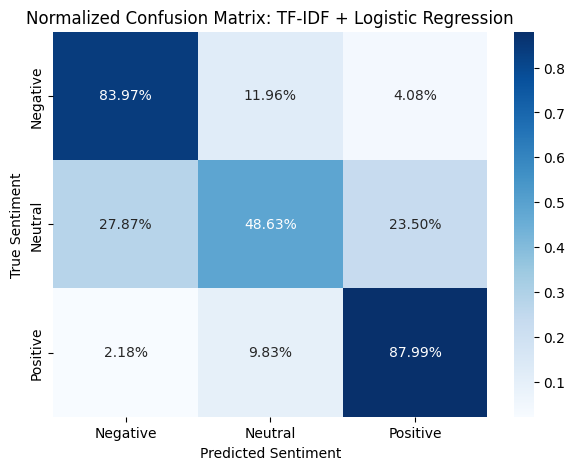

In [6]:
best_model = saved_models['TF-IDF + Logistic Regression']
lr_preds = best_model.predict(X_test)
cm = confusion_matrix(y_test, lr_preds, normalize='true')

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=['Negative', 'Neutral', 'Positive'],
            yticklabels=['Negative', 'Neutral', 'Positive'])
plt.title('Normalized Confusion Matrix: TF-IDF + Logistic Regression')
plt.xlabel('Predicted Sentiment')
plt.ylabel('True Sentiment')
plt.show()
